# LOREM-cu30-lr-mp2：每个 epoch 等变电荷与 SR/LR 能量分析

本 notebook 分析目录 `run/diagnostics/` 下的 `step_*_equivariant_charges.csv`：
- 每个 epoch 前 20 个原子的等变电荷（单极/偶极/四极）
- 每个 epoch 前 20 个原子的短程/长程能量
- 以上量随 epoch 的变化曲线


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True


In [2]:
WORKDIR = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2')
DIAG_DIR = WORKDIR / 'run' / 'diagnostics'
CFG = WORKDIR / 'run' / 'checkpoints' / 'R2_E+F' / 'config.yaml'

assert DIAG_DIR.exists(), f'诊断目录不存在: {DIAG_DIR}'
assert CFG.exists(), f'配置文件不存在: {CFG}'

diag_files = sorted(DIAG_DIR.glob('step_*_equivariant_charges.csv'))
print('diagnostic files:', len(diag_files))
print('first:', diag_files[0].name if diag_files else None)
print('last :', diag_files[-1].name if diag_files else None)


diagnostic files: 998
first: step_00004005_equivariant_charges.csv
last : step_03996990_equivariant_charges.csv


In [3]:
# 从 config.yaml 读 n_train，用于 step -> epoch 映射
n_train = None
with open(CFG, 'r') as f:
    for line in f:
        if line.strip().startswith('n_train:'):
            n_train = int(line.split(':', 1)[1].strip())
            break
if n_train is None:
    n_train = 2000  # fallback

print('n_train =', n_train)

step_re = re.compile(r'step_(\d+)_equivariant_charges\.csv')

def step_from_name(path: Path) -> int:
    m = step_re.match(path.name)
    if m is None:
        raise ValueError(f'Unexpected diagnostics filename: {path.name}')
    return int(m.group(1))


n_train = 2000


In [4]:
# 读取每个 step 的前20原子电荷与能量
rows = []
for f in diag_files:
    step = step_from_name(f)
    epoch = step / n_train
    d = pd.read_csv(f)
    d = d.sort_values('atom_index').head(20).copy()

    # 列映射：
    # scalar_charge -> q0
    # sph_1,sph_2,sph_3 -> q1 (3分量)
    # sph_4..sph_8 -> q2 (5分量)
    d['step'] = step
    d['epoch_est'] = epoch
    d['q0'] = d['scalar_charge']
    d['q1_x'] = d['sph_1']
    d['q1_y'] = d['sph_2']
    d['q1_z'] = d['sph_3']
    d['q1_norm'] = np.sqrt(d['q1_x']**2 + d['q1_y']**2 + d['q1_z']**2)
    d['q2_0'] = d['sph_4']
    d['q2_1'] = d['sph_5']
    d['q2_2'] = d['sph_6']
    d['q2_3'] = d['sph_7']
    d['q2_4'] = d['sph_8']
    d['q2_norm'] = np.sqrt(d[['q2_0','q2_1','q2_2','q2_3','q2_4']].pow(2).sum(axis=1))

    keep = [
        'step', 'epoch_est', 'atom_index', 'Z',
        'q0', 'q1_x', 'q1_y', 'q1_z', 'q1_norm',
        'q2_0', 'q2_1', 'q2_2', 'q2_3', 'q2_4', 'q2_norm',
        'energy_short', 'energy_long'
    ]
    rows.append(d[keep])

top20_df = pd.concat(rows, ignore_index=True)
top20_df.head(30)


,step,epoch_est,atom_index,Z,q0,q1_x,q1_y,q1_z,q1_norm,q2_0,q2_1,q2_2,q2_3,q2_4,q2_norm,energy_short,energy_long
0,4005,2.0025,0.0,6.0,-0.026037,-5.152493e-05,-2.555042e-05,-2.338906e-05,6.208616e-05,-6.769054e-05,-1.470100e-07,-1.601489e-05,5.156014e-05,-6.154914e-06,8.680345e-05,-0.367000,0.360994
1,4005,2.0025,1.0,1.0,0.263499,-9.081090e-09,2.420860e-09,-3.145304e-09,9.910585e-09,-1.093197e-09,-1.273799e-09,1.505313e-08,1.585477e-08,-8.548469e-09,2.353432e-08,-0.023977,0.250593
2,4005,2.0025,2.0,1.0,0.265959,-1.568663e-09,-4.873288e-09,-3.751088e-09,6.346677e-09,-4.963209e-09,-3.347819e-09,6.310795e-09,1.514595e-08,-9.155626e-09,1.972036e-08,-0.074625,0.248061
3,4005,2.0025,3.0,6.0,-0.003719,5.316428e-06,2.150512e-05,2.414820e-05,3.276996e-05,2.823322e-05,-3.510941e-06,1.542405e-05,-1.501073e-05,1.165662e-05,3.753054e-05,0.141094,0.381696
4,4005,2.0025,4.0,6.0,-0.056788,-9.373803e-06,4.636345e-06,-8.200479e-07,1.048982e-05,8.844221e-06,1.460313e-05,-1.514846e-06,-1.334880e-06,1.209344e-05,2.101903e-05,-0.651155,0.357652
5,4005,2.0025,5.0,6.0,-0.046480,9.370009e-06,-9.893077e-06,6.474099e-06,1.508589e-05,5.926918e-06,9.956078e-06,-8.278877e-07,4.403752e-06,6.741335e-06,1.413421e-05,-0.612086,0.360582
6,4005,2.0025,6.0,6.0,-0.032574,7.006829e-06,-8.171431e-06,2.856760e-06,1.113683e-05,2.056360e-05,1.930344e-05,3.359439e-08,9.331315e-06,1.480025e-05,3.319046e-05,-0.668404,0.363191
7,4005,2.0025,7.0,6.0,-0.043667,-8.344417e-06,1.383844e-05,8.744194e-06,1.837369e-05,1.371859e-05,2.063737e-05,3.217766e-06,3.885059e-06,1.189162e-05,2.794565e-05,-0.769910,0.359026
8,4005,2.0025,8.0,6.0,-0.047546,1.136029e-05,-5.717571e-06,1.270069e-05,1.797371e-05,3.000712e-05,2.584325e-05,-1.375057e-05,2.332653e-05,1.713840e-05,5.094340e-05,-0.835774,0.357185
9,4005,2.0025,9.0,6.0,-0.020690,7.460566e-06,-9.620667e-06,4.889667e-06,1.311968e-05,3.096472e-05,4.589918e-05,-1.368650e-05,1.217765e-05,1.408625e-05,5.999655e-05,-0.407953,0.368220


In [ ]:
# 导出“每个epoch前20原子”的完整表
out_csv = WORKDIR / 'epoch_top20_equivariant_charges_and_energies.csv'
top20_df.to_csv(out_csv, index=False)
print('saved:', out_csv)
print('rows:', len(top20_df), ', epochs:', top20_df['step'].nunique())


saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2/epoch_top20_equivariant_charges_and_energies.csv
rows: 12974 , epochs: 998


In [6]:
# 每个epoch聚合统计（用于曲线）
epoch_stats = (
    top20_df.groupby(['step', 'epoch_est'], as_index=False)
    .agg(
        q0_mean=('q0', 'mean'),
        q0_std=('q0', 'std'),
        q1_norm_mean=('q1_norm', 'mean'),
        q2_norm_mean=('q2_norm', 'mean'),
        sr_energy_sum=('energy_short', 'sum'),
        lr_energy_sum=('energy_long', 'sum'),
    )
    .sort_values('step')
    .reset_index(drop=True)
)
epoch_stats.head()


,step,epoch_est,q0_mean,q0_std,q1_norm_mean,q2_norm_mean,sr_energy_sum,lr_energy_sum
0,4005,2.0025,0.058363,0.143531,0.000016,0.000030,-4.140512,4.285957
1,8010,4.0050,-0.121679,0.096767,0.001152,0.001783,-4.060873,3.093547
2,12015,6.0075,0.105885,0.535780,0.005339,0.007820,-3.477333,2.535611
3,16020,8.0100,0.075173,0.898106,0.005240,0.008832,-3.007811,2.486860
4,20025,10.0125,0.290140,0.380441,0.006645,0.011977,-2.741546,2.455748


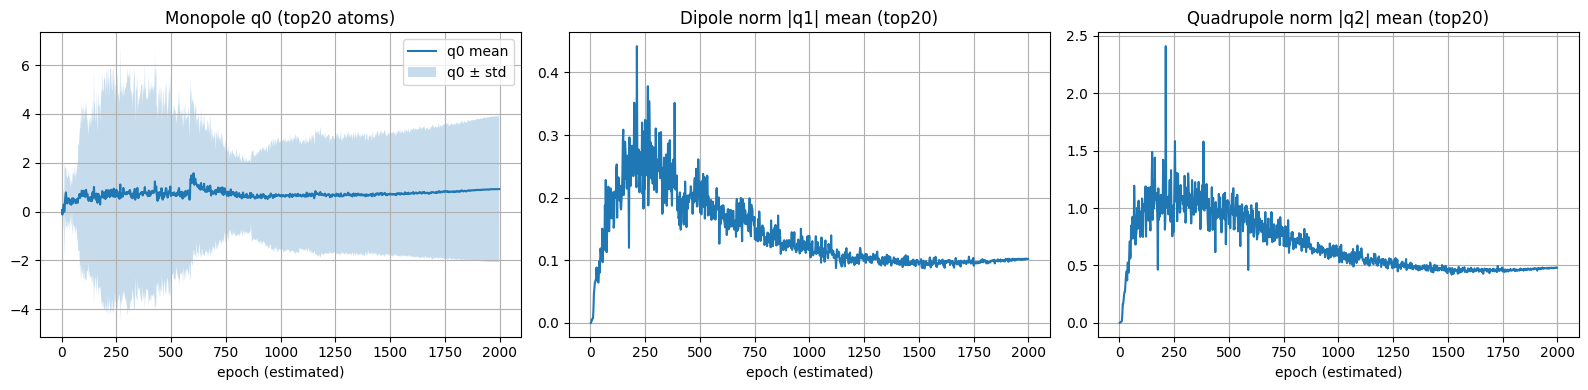

In [7]:
# 曲线1：电荷统计随epoch变化
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

axes[0].plot(epoch_stats['epoch_est'], epoch_stats['q0_mean'], label='q0 mean')
axes[0].fill_between(
    epoch_stats['epoch_est'],
    epoch_stats['q0_mean'] - epoch_stats['q0_std'].fillna(0),
    epoch_stats['q0_mean'] + epoch_stats['q0_std'].fillna(0),
    alpha=0.25,
    label='q0 ± std'
)
axes[0].set_title('Monopole q0 (top20 atoms)')
axes[0].set_xlabel('epoch (estimated)')
axes[0].legend()

axes[1].plot(epoch_stats['epoch_est'], epoch_stats['q1_norm_mean'])
axes[1].set_title('Dipole norm |q1| mean (top20)')
axes[1].set_xlabel('epoch (estimated)')

axes[2].plot(epoch_stats['epoch_est'], epoch_stats['q2_norm_mean'])
axes[2].set_title('Quadrupole norm |q2| mean (top20)')
axes[2].set_xlabel('epoch (estimated)')

plt.tight_layout()
plt.show()


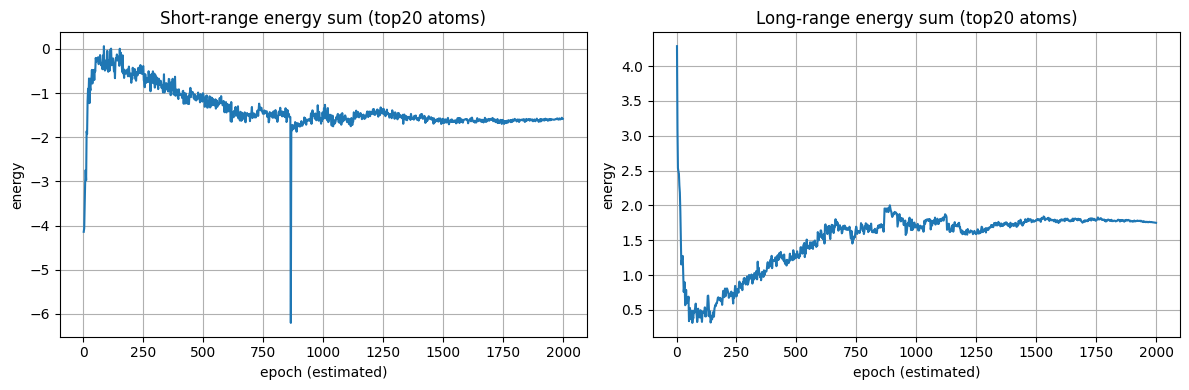

In [8]:
# 曲线2：短程/长程能量随epoch变化
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(epoch_stats['epoch_est'], epoch_stats['sr_energy_sum'])
axes[0].set_title('Short-range energy sum (top20 atoms)')
axes[0].set_xlabel('epoch (estimated)')
axes[0].set_ylabel('energy')

axes[1].plot(epoch_stats['epoch_est'], epoch_stats['lr_energy_sum'])
axes[1].set_title('Long-range energy sum (top20 atoms)')
axes[1].set_xlabel('epoch (estimated)')
axes[1].set_ylabel('energy')

plt.tight_layout()
plt.show()


In [9]:
# 单独查看某个epoch（前20原子详细值）
target_step = int(epoch_stats['step'].iloc[-1])  # 默认最后一个
view_df = top20_df[top20_df['step'] == target_step].copy().sort_values('atom_index')
print('target_step =', target_step, ', epoch_est =', float(view_df['epoch_est'].iloc[0]))
display(view_df)


target_step = 3996990 , epoch_est = 1998.495


,step,epoch_est,atom_index,Z,q0,q1_x,q1_y,q1_z,q1_norm,q2_0,q2_1,q2_2,q2_3,q2_4,q2_norm,energy_short,energy_long
12961,3996990,1998.495,0.0,6.0,-0.924648,0.004587,0.015509,-0.003550,0.016558,0.010500,-0.001304,-0.012746,-0.014432,0.007566,0.023237,-0.436194,0.128675
12962,3996990,1998.495,1.0,1.0,5.229890,0.009730,0.002579,0.007734,0.012694,-0.001319,-0.001972,-0.002083,-0.001885,-0.000058,0.003678,-0.152669,0.169311
12963,3996990,1998.495,2.0,1.0,5.264592,-0.015744,0.016384,0.001285,0.022759,0.000504,0.001649,-0.000915,-0.001049,0.001533,0.002695,-0.160029,0.169517
12964,3996990,1998.495,3.0,6.0,-0.939621,0.112968,0.016231,0.024753,0.116781,-0.016544,0.035288,-0.067595,-0.018149,0.010684,0.080818,-0.129400,0.138945
12965,3996990,1998.495,4.0,6.0,-0.967777,0.004798,0.226826,0.061584,0.235086,0.022074,-0.105368,-0.465289,-0.190818,0.179148,0.544600,0.117196,0.159279
12966,3996990,1998.495,5.0,6.0,-0.943848,-0.187317,-0.160852,-0.024298,0.248095,-0.128093,0.576718,2.229231,1.399831,-0.865775,2.833297,0.072069,0.035404
12967,3996990,1998.495,6.0,6.0,-1.054531,0.010704,-0.003960,0.027386,0.029669,0.023899,0.035163,-0.027890,-0.011900,-0.006527,0.052627,-0.062739,0.121410
12968,3996990,1998.495,7.0,6.0,-1.056219,-0.008074,0.229348,-0.033333,0.231898,0.377126,0.551848,-0.823590,-0.655779,-1.802899,2.192157,-0.058937,0.058668
12969,3996990,1998.495,8.0,6.0,-1.046235,0.085263,-0.169870,0.051584,0.196943,-0.119511,-0.122576,0.112464,0.151634,0.384708,0.461464,-0.066921,0.155220
12970,3996990,1998.495,9.0,6.0,-1.012192,0.096126,-0.055082,-0.010109,0.111250,-0.004851,-0.015574,0.009180,0.022592,0.009743,0.030914,-0.277398,0.142520


In [10]:
# 保存聚合曲线数据
epoch_csv = WORKDIR / 'epoch_top20_charge_energy_curves.csv'
epoch_stats.to_csv(epoch_csv, index=False)
print('saved:', epoch_csv)
epoch_stats.tail()


saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2/epoch_top20_charge_energy_curves.csv


,step,epoch_est,q0_mean,q0_std,q1_norm_mean,q2_norm_mean,sr_energy_sum,lr_energy_sum
993,3980970,1990.4850,0.916766,2.973299,0.102627,0.481881,-1.588114,1.754975
994,3984975,1992.4875,0.919594,2.979392,0.102039,0.479087,-1.576109,1.753372
995,3988980,1994.4900,0.922259,2.988066,0.102189,0.478638,-1.557013,1.751899
996,3992985,1996.4925,0.920859,2.987731,0.102256,0.481274,-1.579821,1.751125
997,3996990,1998.4950,0.922170,2.989720,0.102279,0.480833,-1.583376,1.750262


## 复现 cumulene 二面角能量曲线（参考 `results_cumulene.py`）

下面代码按 `experiments/results_cumulene.py` 的流程绘图：
- 横轴：二面角（按角度排序）
- 纵轴：相对势能（各自减去最小值）
- 两条曲线：预测能量 vs DFT 能量

优先使用当前目录已有的 `cumulene_dihedral_energy_curve.npz`；如果没有该文件，再尝试用 checkpoint 和 `cumulene_profile.xyz` 现场重算。

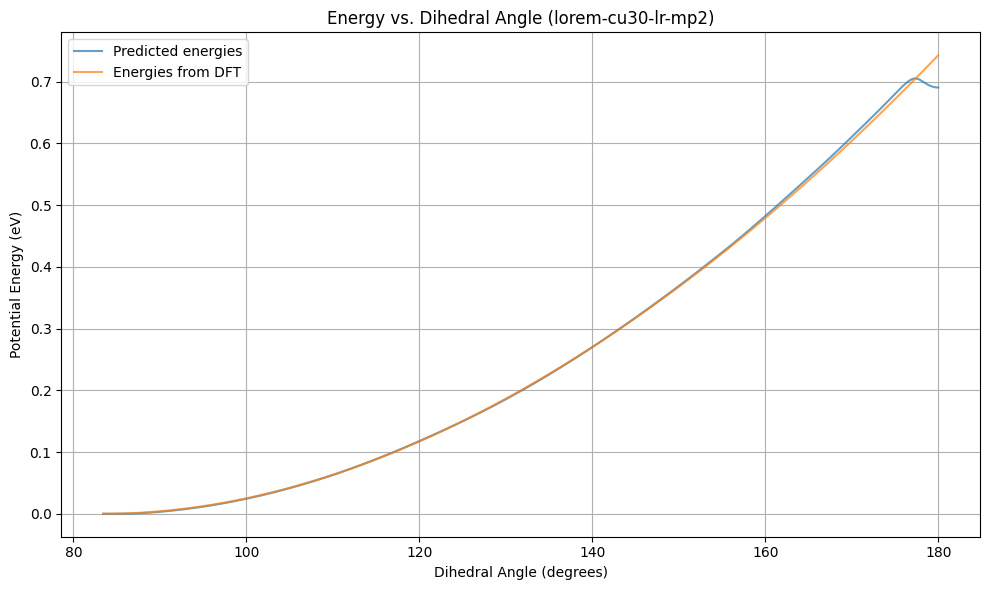

Saved plot to: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2/cumulene_dihedral_energy_curve_replot.png
Saved data to: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2/cumulene_dihedral_energy_curve_replot.npz


In [13]:
# 与 results_cumulene.py 一致风格：强制用 checkpoint + cumulene_profile.xyz 重算
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

workdir = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2')
lorem_root = Path('/data/home/public/qiuqizhi/LOREM')
dataset_folder = lorem_root / 'datasets'
checkpoint_dir = workdir / 'run' / 'checkpoints' / 'R2_E+F'
out_path = workdir / 'cumulene_dihedral_energy_curve_replot.png'

# 使用 LOREM 原生 calculator
sys.path.insert(0, str(lorem_root / 'lorem'))
from calculator import Calculator


def assign_calculators(systems, calculator):
    for system in systems:
        system.calc = calculator


def order_by_dihedrals(systems, atom_indices=(0, 1, 11, 12)):
    dihedrals_local = np.array([sys.get_dihedral(*atom_indices) for sys in systems])
    order = np.argsort(dihedrals_local)
    systems[:] = [systems[i] for i in order]
    return dihedrals_local[order]


def get_energies(systems):
    energies = [sys.get_potential_energy() for sys in systems]
    min_e = min(energies)
    return np.array([e - min_e for e in energies])


xyz_path = dataset_folder / 'cumulene_profile.xyz'
assert xyz_path.exists(), f'数据文件不存在: {xyz_path}'
assert checkpoint_dir.exists(), f'checkpoint 不存在: {checkpoint_dir}'

systems = read(xyz_path, index=':')
dihedrals = order_by_dihedrals(systems)
actual_energies = get_energies(systems)

calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)
assign_calculators(systems, calc)
predicted_energies = get_energies(systems)

# 按 results_cumulene.py 的绘图风格
plt.figure(figsize=(10, 6))
plt.plot(dihedrals, predicted_energies, label='Predicted energies', alpha=0.7)
plt.plot(dihedrals, actual_energies, label='Energies from DFT', alpha=0.7)
plt.xlabel('Dihedral Angle (degrees)')
plt.ylabel('Potential Energy (eV)')
plt.legend()
plt.title(f'Energy vs. Dihedral Angle ({workdir.stem})')
plt.tight_layout()
plt.savefig(out_path, dpi=200)
plt.show()

print('Saved plot to:', out_path)

# 保存本次重算数据
replot_npz = workdir / 'cumulene_dihedral_energy_curve_replot.npz'
np.savez(
    replot_npz,
    dihedrals=dihedrals,
    predicted_energies=predicted_energies,
    actual_energies=actual_energies,
)
print('Saved data to:', replot_npz)

## 用 checkpoint 预测时分解输出 short/long 能量

下面这段代码不是只拿 `Calculator.get_potential_energy()` 的总能量，而是像 `run.py` 的 `diagnostics_fn` 一样，调用模型 `apply(..., mutable=['intermediates'])`，读取：
- `diag_energy_short_raw`
- `diag_energy_long_raw`

然后对每个结构求和，得到每个二面角点的：
- `energy_total_pred`
- `energy_short_pred`
- `energy_long_pred`


saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2/cumulene_dihedral_energy_curve_split.csv
   dihedral_deg  actual_rel_e  pred_total_rel_e  pred_short_rel_e  \
0     83.424819      0.000000          0.000034          0.000003   
1     83.513758      0.000000          0.000034          0.000003   
2     83.602712      0.000008          0.000032          0.000003   
3     83.691682      0.000008          0.000030          0.000003   
4     83.780669      0.000015          0.000027          0.000004   

   pred_long_rel_e  pred_total_abs_e  pred_short_abs_e  pred_long_abs_e  
0         0.000034         -2.421612         -3.902918         1.481306  
1         0.000034         -2.421613         -3.902919         1.481306  
2         0.000032         -2.421614         -3.902918         1.481304  
3         0.000030         -2.421617         -3.902919         1.481302  
4         0.000027         -2.421619         -3.902918         1.481299  


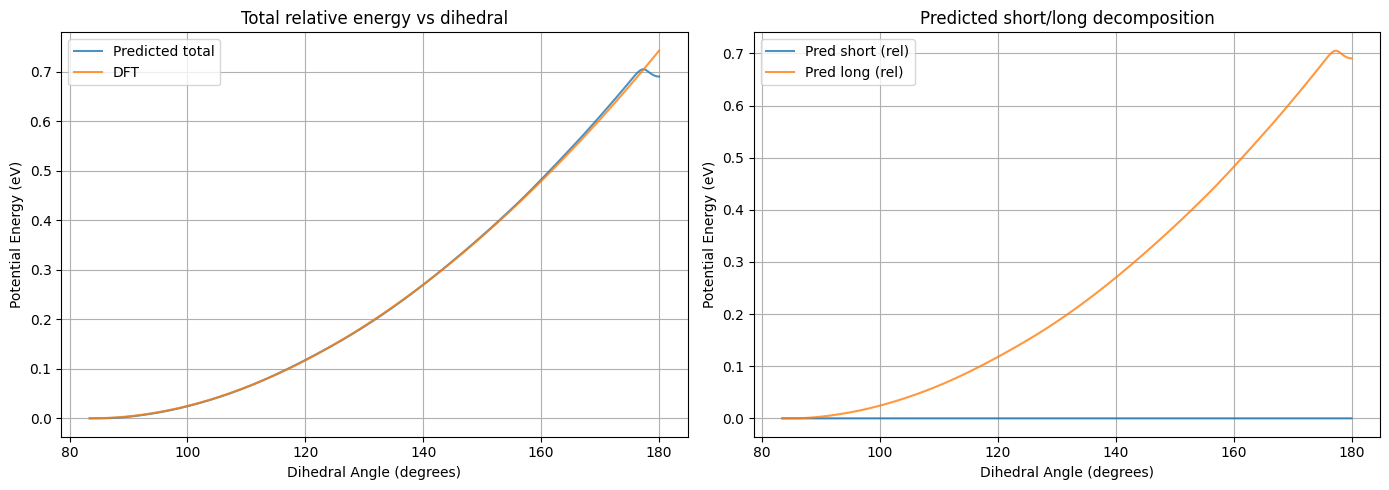

max |total - (short+long)| = 4.76837158203125e-07
long abs min/max = 1.4812719821929932 2.1865949630737305


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from ase.io import read

import sys
lorem_src = '/data/home/public/qiuqizhi/LOREM/lorem'
if lorem_src not in sys.path:
    sys.path.insert(0, lorem_src)

from calculator import Calculator
from marathon.io import from_dict, read_yaml
from marathon.emit.checkpoint import read_msgpack

workdir = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2')
dataset_folder = Path('/data/home/public/qiuqizhi/LOREM/datasets')
checkpoint_dir = workdir / 'run' / 'checkpoints' / 'R2_E+F'
xyz_path = dataset_folder / 'cumulene_profile.xyz'

assert checkpoint_dir.exists(), f'checkpoint not found: {checkpoint_dir}'
assert xyz_path.exists(), f'xyz not found: {xyz_path}'

# 1) 加载模型与参数（与 Calculator.from_checkpoint 的来源一致）
model = from_dict(read_yaml(checkpoint_dir / 'model' / 'model.yaml'))
_ = model.init(jax.random.key(1), *model.dummy_inputs())
params = read_msgpack(checkpoint_dir / 'model' / 'model.msgpack')

# 2) 准备系统并按二面角排序（与 results_cumulene.py 对齐）
systems = read(xyz_path, index=':')
dihedrals = np.array([sys.get_dihedral(0, 1, 11, 12) for sys in systems])
order = np.argsort(dihedrals)
systems = [systems[i] for i in order]
dihedrals = dihedrals[order]

# DFT 相对能量（参考）
actual = np.array([sys.get_potential_energy() for sys in systems], dtype=float)
actual = actual - actual.min()

# 3) 定义与 run.py 一致的诊断函数（提取 raw short/long）
@jax.jit
def diagnostics_fn(params, batch):
    energies, vars_out = model.apply(
        params,
        batch.edges,
        batch.centers,
        batch.others,
        batch.nodes,
        batch.edge_mask,
        batch.node_mask,
        batch.positions,
        batch.cell,
        batch.k_grid,
        batch.smearing,
        batch.full_edges,
        batch.full_centers,
        batch.full_others,
        batch.full_edge_mask,
        mutable=['intermediates'],
    )
    diag = vars_out['intermediates']
    node_mask = batch.node_mask

    e_total = jnp.sum(energies * node_mask)
    e_short = jnp.sum(diag['diag_energy_short_raw'][0] * node_mask)
    e_long = jnp.sum(diag['diag_energy_long_raw'][0] * node_mask)
    return e_total, e_short, e_long

# 4) 逐结构计算 total/short/long
calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)

pred_total = []
pred_short = []
pred_long = []
for sys in systems:
    # 先触发 batch 构建
    calc.update(sys)
    batch = calc.batch

    e_total, e_short, e_long = diagnostics_fn(params, batch)
    pred_total.append(float(e_total))
    pred_short.append(float(e_short))
    pred_long.append(float(e_long))

pred_total = np.array(pred_total)
pred_short = np.array(pred_short)
pred_long = np.array(pred_long)

# 各自做相对能量（减最小值），便于曲线比较
pred_total_rel = pred_total - pred_total.min()
pred_short_rel = pred_short - pred_short.min()
pred_long_rel = pred_long - pred_long.min()

# 保存分解数据
split_df = pd.DataFrame({
    'dihedral_deg': dihedrals,
    'actual_rel_e': actual,
    'pred_total_rel_e': pred_total_rel,
    'pred_short_rel_e': pred_short_rel,
    'pred_long_rel_e': pred_long_rel,
    'pred_total_abs_e': pred_total,
    'pred_short_abs_e': pred_short,
    'pred_long_abs_e': pred_long,
})

split_csv = workdir / 'cumulene_dihedral_energy_curve_split.csv'
split_df.to_csv(split_csv, index=False)
print('saved:', split_csv)
print(split_df.head())

# 5) 画图：总能量对比 + short/long 分解
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(dihedrals, pred_total_rel, label='Predicted total', alpha=0.8)
axes[0].plot(dihedrals, actual, label='DFT', alpha=0.8)
axes[0].set_title('Total relative energy vs dihedral')
axes[0].set_xlabel('Dihedral Angle (degrees)')
axes[0].set_ylabel('Potential Energy (eV)')
axes[0].legend()

axes[1].plot(dihedrals, pred_short_rel, label='Pred short (rel)', alpha=0.8)
axes[1].plot(dihedrals, pred_long_rel, label='Pred long (rel)', alpha=0.8)
axes[1].set_title('Predicted short/long decomposition')
axes[1].set_xlabel('Dihedral Angle (degrees)')
axes[1].set_ylabel('Potential Energy (eV)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 一些快速检查量
print('max |total - (short+long)| =', np.max(np.abs(pred_total - (pred_short + pred_long))))
print('long abs min/max =', float(pred_long.min()), float(pred_long.max()))

## 导出每个构型的原子电荷信息（q0/q1/q2）

上面的 `cumulene_dihedral_energy_curve_split.csv` 是“每个二面角构型”的总能量分解。
如果需要看“每个原子”的电荷，这里额外导出：
- 标量电荷 `q0`
- 球谐电荷分量（按 `l=0,1,2` 切分）
- `q1_norm`、`q2_norm`

输出文件：`cumulene_dihedral_atom_charges.csv`。

In [ ]:
# 依赖上一段代码中的 model / params / systems / dihedrals / checkpoint_dir
# 如果你只想导出一部分构型或原子，可调下面两个参数
MAX_STRUCTURES = None          # 例如 50；None 表示全部构型
MAX_ATOMS_PER_STRUCTURE = None # 例如 20；None 表示全部原子

@jax.jit
def charge_diag_fn(params, batch):
    _, vars_out = model.apply(
        params,
        batch.edges,
        batch.centers,
        batch.others,
        batch.nodes,
        batch.edge_mask,
        batch.node_mask,
        batch.positions,
        batch.cell,
        batch.k_grid,
        batch.smearing,
        batch.full_edges,
        batch.full_centers,
        batch.full_others,
        batch.full_edge_mask,
        mutable=['intermediates'],
    )
    d = vars_out['intermediates']
    return (
        d['diag_scalar_charges_raw'][0],
        d['diag_spherical_charges_raw'][0],
        batch.node_mask,
        batch.nodes,
    )

calc = Calculator.from_checkpoint(checkpoint_dir, add_offset=False)

rows = []
num_structures = len(systems) if MAX_STRUCTURES is None else min(MAX_STRUCTURES, len(systems))

for i in range(num_structures):
    sys_i = systems[i]
    dih_i = float(dihedrals[i])

    calc.update(sys_i)
    batch = calc.batch

    scalar_raw, spherical_raw, node_mask, node_species = charge_diag_fn(params, batch)

    scalar_raw = np.asarray(scalar_raw)
    spherical_raw = np.asarray(spherical_raw)
    node_mask = np.asarray(node_mask).astype(bool)
    node_species = np.asarray(node_species)

    if node_species.ndim > 1:
        node_species = np.argmax(node_species, axis=-1)

    atom_idx = np.where(node_mask)[0]
    if MAX_ATOMS_PER_STRUCTURE is not None:
        atom_idx = atom_idx[:MAX_ATOMS_PER_STRUCTURE]

    for j in atom_idx:
        q0 = float(scalar_raw[j, 0])

        # spherical 按 l=0,1,2 切分（当前 max_degree_lr=2）
        # 宽度分别是 1,3,5，共 9 维
        sph = spherical_raw[j]
        q_l0 = sph[0:1]
        q_l1 = sph[1:4] if sph.shape[0] >= 4 else np.array([np.nan, np.nan, np.nan])
        q_l2 = sph[4:9] if sph.shape[0] >= 9 else np.array([np.nan] * 5)

        rows.append({
            'structure_index': i,
            'dihedral_deg': dih_i,
            'atom_index': int(j),
            'Z': int(node_species[j]),
            'q0': q0,
            'q_l0_0': float(q_l0[0]) if len(q_l0) > 0 else np.nan,
            'q_l1_0': float(q_l1[0]),
            'q_l1_1': float(q_l1[1]),
            'q_l1_2': float(q_l1[2]),
            'q_l1_norm': float(np.linalg.norm(q_l1)),
            'q_l2_0': float(q_l2[0]),
            'q_l2_1': float(q_l2[1]),
            'q_l2_2': float(q_l2[2]),
            'q_l2_3': float(q_l2[3]),
            'q_l2_4': float(q_l2[4]),
            'q_l2_norm': float(np.linalg.norm(q_l2)),
        })

charges_df = pd.DataFrame(rows)
charges_csv = workdir / 'cumulene_dihedral_atom_charges.csv'
charges_df.to_csv(charges_csv, index=False)

print('saved:', charges_csv)
print('shape:', charges_df.shape)
print('\n示例（前30行）:')
display(charges_df.head(30))

saved: /data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/lorem-cu30-lr-mp2/cumulene_dihedral_atom_charges.csv
shape: (13000, 16)

示例（前30行）:


,structure_index,dihedral_deg,atom_index,Z,q0,q_l0_0,q_l1_0,q_l1_1,q_l1_2,q_l1_norm,q_l2_0,q_l2_1,q_l2_2,q_l2_3,q_l2_4,q_l2_norm
0,0,83.424819,0,6,-0.838336,-0.017303,-4.248257e-02,-3.271018e-09,0.000000e+00,4.248257e-02,-0.006702,9.641259e-10,0.000000e+00,0.000000,0.005513,0.008678
1,0,83.424819,1,1,4.300817,-0.000986,-1.224725e-02,-1.227010e-02,0.000000e+00,1.733639e-02,0.000678,-1.725813e-03,0.000000e+00,0.000000,0.001584,0.002438
2,0,83.424819,2,1,4.300817,-0.000986,-1.224725e-02,1.227010e-02,0.000000e+00,1.733639e-02,0.000678,1.725813e-03,0.000000e+00,0.000000,0.001584,0.002438
3,0,83.424819,3,6,-0.841598,-0.062356,-2.459251e-02,2.540339e-09,0.000000e+00,2.459251e-02,0.019750,3.409370e-10,0.000000e+00,0.000000,0.059469,0.062663
4,0,83.424819,4,6,-0.870629,-0.254470,-1.370528e-01,0.000000e+00,0.000000e+00,1.370528e-01,0.298157,0.000000e+00,0.000000e+00,0.000000,0.563801,0.637785
5,0,83.424819,5,6,-0.851963,-1.383196,1.144754e-01,0.000000e+00,0.000000e+00,1.144754e-01,-1.035645,0.000000e+00,0.000000e+00,0.000000,-2.270671,2.495698
6,0,83.424819,6,6,-0.890962,-0.011200,-1.914294e-09,0.000000e+00,0.000000e+00,1.914294e-09,-0.010931,0.000000e+00,0.000000e+00,0.000000,0.006311,0.012622
7,0,83.424819,7,6,-0.851963,-1.383196,-1.144755e-01,0.000000e+00,0.000000e+00,1.144755e-01,1.448637,0.000000e+00,0.000000e+00,0.000000,2.032230,2.495698
8,0,83.424819,8,6,-0.870629,-0.254470,1.370528e-01,0.000000e+00,0.000000e+00,1.370528e-01,-0.339188,0.000000e+00,0.000000e+00,0.000000,-0.540113,0.637785
9,0,83.424819,9,6,-0.841598,-0.062356,2.459238e-02,0.000000e+00,6.399155e-10,2.459238e-02,-0.041627,0.000000e+00,1.731081e-10,0.000000,-0.046839,0.062663


: 